# Chapter 4 — Equation of state of GaAs

Companion notebook to Chapter 4. We fit the total-energy-vs-volume data
(`code/04-relaxation/eos.dat`) to the **Birch–Murnaghan** equation of
state to extract the equilibrium lattice constant $a_0$ and the bulk
modulus $B_0$, then compare $a_0$ with experiment. Requirements:
`numpy`, `scipy`, `matplotlib`.

In [1]:
import numpy as np
from scipy.optimize import curve_fit
from pathlib import Path

BOHR_TO_ANG = 0.52917721
RYB3_TO_GPA = 14710.5   # 1 Ry/bohr^3 in GPa

a_bohr, E = np.loadtxt('../code/04-relaxation/eos.dat', skiprows=1, unpack=True)
V = a_bohr**3 / 4.0      # zincblende primitive cell volume = a^3/4 (2 atoms)

def birch_murnaghan(V, E0, V0, B0, B0p):
    eta = (V0 / V)**(2.0/3.0)
    return E0 + 9*V0*B0/16 * ((eta-1)**3 * B0p + (eta-1)**2 * (6 - 4*eta))

p0 = [E.min(), V[np.argmin(E)], 0.005, 4.0]
popt, _ = curve_fit(birch_murnaghan, V, E, p0=p0)
E0, V0, B0, B0p = popt

a0_bohr = (4*V0)**(1.0/3.0)
a0_ang = a0_bohr * BOHR_TO_ANG
a_exp = 5.653
print(f'Equilibrium (PBE):  a0 = {a0_ang:.4f} Ang   ({a0_bohr:.4f} bohr)')
print(f'Experiment:         a0 = {a_exp:.4f} Ang')
print(f'PBE overestimate:   {100*(a0_ang-a_exp)/a_exp:+.2f} %')
print(f'Bulk modulus B0  =  {B0*RYB3_TO_GPA:.1f} GPa   (exp ~ 75 GPa)')

Equilibrium (PBE):  a0 = 5.7562 Ang   (10.8776 bohr)
Experiment:         a0 = 5.6530 Ang
PBE overestimate:   +1.83 %
Bulk modulus B0  =  59.7 GPa   (exp ~ 75 GPa)


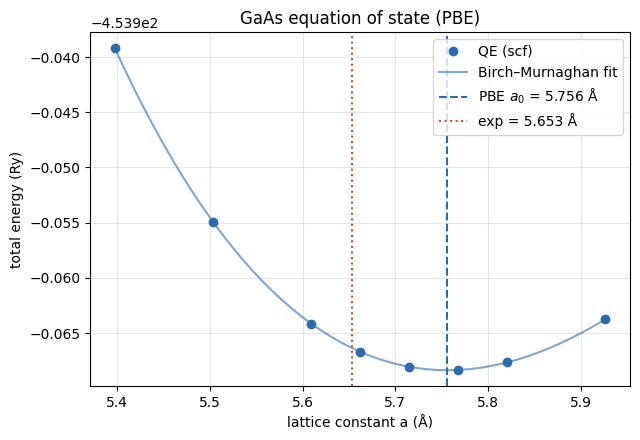

In [2]:
import matplotlib.pyplot as plt

aa = a_bohr * BOHR_TO_ANG
afit = np.linspace(a_bohr.min(), a_bohr.max(), 200)
Efit = birch_murnaghan(afit**3/4.0, *popt)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(aa, E, 'o', color='#2b6cb0', label='QE (scf)')
ax.plot(afit*BOHR_TO_ANG, Efit, '-', color='#2b6cb0', alpha=0.6, label='Birch–Murnaghan fit')
ax.axvline(a0_ang, ls='--', color='#2b6cb0', label=f'PBE $a_0$ = {a0_ang:.3f} Å')
ax.axvline(5.653, ls=':', color='#c05621', label='exp = 5.653 Å')
ax.set_xlabel('lattice constant a (Å)')
ax.set_ylabel('total energy (Ry)')
ax.set_title('GaAs equation of state (PBE)')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
out_png = Path('../static/img/04-eos.png')
fig.savefig(out_png, dpi=120)
plt.show()

**What you see.** The energy traces a smooth well; its minimum is the
equilibrium lattice constant. PBE lands a bit to the **right** of the
experimental value (here by ~1.8 %) — GGA functionals systematically
*overestimate* lattice constants of semiconductors. The curvature of the well
gives the bulk modulus $B_0$. A `vc-relax` calculation finds this same
minimum automatically, by following the stress to zero, instead of
scanning the whole curve.